# Notebook 10: Ensemble Methods & Model Optimization

## Project: Indian Air Quality Index (AQI) Comprehensive Analysis
## BTech Final Year Project - Data Science & Machine Learning (8th Semester)

### Objective:
Build ensemble models (stacking, voting), perform hyperparameter tuning with GridSearchCV and RandomizedSearchCV, and create the final optimized AQI prediction model.

### Prerequisites:
- Complete Notebook 05 (regression models)
- Libraries: pandas, numpy, scikit-learn, xgboost, lightgbm

### Run Time: 30-45 minutes

## Step 1: Import Libraries & Load Data

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import VotingRegressor, StackingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Libraries imported!')


Libraries imported!


### Explanation:

- **from sklearn.ensemble import VotingRegressor**: Ensemble that averages predictions from multiple models.

- **from sklearn.ensemble import StackingRegressor**: Stacked ensemble (meta-learner combines base model predictions).

- **from sklearn.model_selection import GridSearchCV**: Exhaustive search over specified hyperparameter values.

- **from sklearn.model_selection import RandomizedSearchCV**: Random search over hyperparameters (faster than grid search).

In [32]:
# Load data
X_train = pd.read_csv(os.path.join('..', 'datasets', 'X_train.csv'))
X_test = pd.read_csv(os.path.join('..', 'datasets', 'X_test.csv'))
y_train = pd.read_csv(os.path.join('..', 'datasets', 'y_train_reg.csv')).values.ravel()
y_test = pd.read_csv(os.path.join('..', 'datasets', 'y_test_reg.csv')).values.ravel()
print(f'Loaded {X_train.shape[0]} training and {X_test.shape[0]} test samples')

Loaded 354146 training and 88537 test samples


## Step 2: Build Voting Ensemble

In [33]:
estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('lgbm', LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
]
voting = VotingRegressor(estimators)
voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_voting))
r2 = r2_score(y_test, y_pred_voting)
print(f'Voting Ensemble Performance:')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5712
[LightGBM] [Info] Number of data points in the train set: 354146, number of used features: 31
[LightGBM] [Info] Start training from score 117.988929
Voting Ensemble Performance:
RMSE: 5.45
R²: 0.9954
Voting Ensemble Performance:
RMSE: 5.45
R²: 0.9954


### Explanation:

- **VotingRegressor**: Averages predictions from multiple diverse models.

- **estimators**: List of (name, model) tuples.

- **Diversity**: Using different model types (RF, XGB, LGBM) improves ensemble performance.

## Step 3: Build Stacking Ensemble

In [35]:
## Step 3: Build Stacking Ensemble (OPTIMIZED FOR SPEED)
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Use smaller models and parallel processing for speed
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1)),
    ('xgb', XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1, tree_method='hist')),
    ('lgbm', LGBMRegressor(n_estimators=50, learning_rate=0.1, max_depth=7, random_state=42, n_jobs=-1))
]

print('Training Stacking Ensemble (optimized)...')
stacking = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(),
    cv=3,
    n_jobs=-1  # CRITICAL: Use all CPU cores!
)
stacking.fit(X_train_imputed, y_train)
y_pred_stacking = stacking.predict(X_test_imputed)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stacking))
r2_stack = r2_score(y_test, y_pred_stacking)
print(f'Stacking Ensemble Performance:')
print(f'RMSE: {rmse_stack:.2f}')
print(f'R²: {r2_stack:.4f}')

Training Stacking Ensemble (optimized)...
Stacking Ensemble Performance:
RMSE: 4.97
R²: 0.9962
Stacking Ensemble Performance:
RMSE: 4.97
R²: 0.9962


### Explanation:

- **StackingRegressor**: Meta-learner learns to combine base model predictions optimally.

- **base_estimators**: Models that make initial predictions.

- **final_estimator=Ridge()**: Meta-model that learns best combination of base predictions.

- **cv=5**: 5-fold cross-validation for generating meta-features.

## Step 4: Hyperparameter Tuning - Random Forest (GridSearchCV)

In [36]:
# Step 4: Hyperparameter Tuning - Random Forest (GridSearchCV) - STANDALONE VERSION
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Load data (in case Step 1 wasn't run)
X_train = pd.read_csv(os.path.join('..', 'datasets', 'X_train.csv'))
X_test = pd.read_csv(os.path.join('..', 'datasets', 'X_test.csv'))
y_train = pd.read_csv(os.path.join('..', 'datasets', 'y_train_reg.csv')).values.ravel()
y_test = pd.read_csv(os.path.join('..', 'datasets', 'y_test_reg.csv')).values.ravel()
print(f'Loaded {X_train.shape[0]} training and {X_test.shape[0]} test samples')

# Reduced parameter grid for faster execution
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

# Use 20% of data for speed
sample_size = int(len(X_train) * 0.2)
X_train_small = X_train.iloc[:sample_size]
y_train_small = y_train[:sample_size]
print(f'Using {sample_size} samples for faster tuning')

# GridSearchCV with minimal settings
grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), 
    param_grid_rf, 
    cv=2, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=1
)
grid_search_rf.fit(X_train_small, y_train_small)
print(f'\nBest RF Parameters: {grid_search_rf.best_params_}')
print(f'Best R²: {grid_search_rf.best_score_:.4f}')

Loaded 354146 training and 88537 test samples
Using 70829 samples for faster tuning
Fitting 2 folds for each of 8 candidates, totalling 16 fits

Best RF Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best R²: 0.9908

Best RF Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best R²: 0.9908


### Explanation:

- **param_grid_rf**: Dictionary of hyperparameters to search.

- **GridSearchCV**: Tests ALL combinations (3×4×3 = 36 combinations).

- **cv=3**: 3-fold cross-validation for each combination.

- **scoring='r2'**: Uses R-squared to evaluate combinations.

- **best_params_**: Optimal hyperparameter combination found.

## Step 5: Hyperparameter Tuning - XGBoost (RandomizedSearchCV)

In [38]:
## Step 5: Hyperparameter Tuning - XGBoost (RandomizedSearchCV)
# Import missing libraries
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
## Step 5: Hyperparameter Tuning - XGBoost (RandomizedSearchCV)
# Define parameter distribution (optimized for speed)
param_dist_xgb = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [5, 7, 10],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Use 40% of data to avoid MemoryError (177K samples instead of 442K)
sample_size = int(len(X_train) * 0.4)
X_train_xgb = X_train.iloc[:sample_size]
y_train_xgb = y_train[:sample_size]
print(f'Using {sample_size:,} samples (40%) to prevent memory issues')
print(f'Testing 20 random combinations with 3-fold CV (60 total fits)')
print(f'Expected time: 5-8 minutes\n')

# RandomizedSearchCV with n_jobs=1 to avoid memory issues
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

random_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, tree_method='hist'),  # Remove n_jobs=-1
    param_distributions=param_dist_xgb,
    n_iter=20,  # Reduced from 30 for speed
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=1,  # CRITICAL: Set to 1 to avoid MemoryError!
    verbose=1,
    return_train_score=True
)

random_xgb.fit(X_train_xgb, y_train_xgb)

print(f'\n✓ Best XGB Parameters: {random_xgb.best_params_}')
print(f'✓ Best CV R² Score: {random_xgb.best_score_:.4f}')

Using 141,658 samples (40%) to prevent memory issues
Testing 20 random combinations with 3-fold CV (60 total fits)
Expected time: 5-8 minutes

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✓ Best XGB Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.15, 'colsample_bytree': 1.0}
✓ Best CV R² Score: 0.9946

✓ Best XGB Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.15, 'colsample_bytree': 1.0}
✓ Best CV R² Score: 0.9946


### Explanation:

- **RandomizedSearchCV**: Tests RANDOM combinations (faster than grid search).

- **n_iter=50**: Tests 50 random combinations.

- **Faster**: Doesn't test all combinations, finds good parameters quickly.

## Step 6: Evaluate Optimized Models

In [40]:
## Step 6: Evaluate Optimized Models
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score

# Create imputed data (if not already done in Step 3)
try:
    X_test_imputed
except NameError:
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)

# Get best estimators from hyperparameter searches
best_rf = grid_search_rf.best_estimator_
best_xgb = random_xgb.best_estimator_

# Make predictions
y_pred_rf_opt = best_rf.predict(X_test_imputed)
y_pred_xgb_opt = best_xgb.predict(X_test_imputed)

print('Optimized Models Performance:')
print(f'Optimized RF - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_opt)):.2f}, R²: {r2_score(y_test, y_pred_rf_opt):.4f}')
print(f'Optimized XGB - RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_opt)):.2f}, R²: {r2_score(y_test, y_pred_xgb_opt):.4f}')

Optimized Models Performance:
Optimized RF - RMSE: 7.48, R²: 0.9913
Optimized XGB - RMSE: 16.67, R²: 0.9566


## Step 7: Compare All Approaches

In [43]:
## Step 7: Compare All Approaches

# Check which variable names exist and use them
try:
    # Try the voting/stacking naming convention first
    rmse_vote = rmse_voting
    r2_vote = r2_voting
    rmse_stack_val = rmse_stacking
    r2_stack_val = r2_stacking
except NameError:
    # Fallback to simpler naming (rmse, r2 from Step 2, rmse_stack, r2_stack from Step 3)
    rmse_vote = rmse
    r2_vote = r2
    rmse_stack_val = rmse_stack
    r2_stack_val = r2_stack

comparison = pd.DataFrame({
    'Model': ['Voting Ensemble', 'Stacking Ensemble', 'Optimized RF', 'Optimized XGB'],
    'RMSE': [rmse_vote, rmse_stack_val, np.sqrt(mean_squared_error(y_test, y_pred_rf_opt)), 
             np.sqrt(mean_squared_error(y_test, y_pred_xgb_opt))],
    'R²': [r2_vote, r2_stack_val, r2_score(y_test, y_pred_rf_opt), r2_score(y_test, y_pred_xgb_opt)]
})
print('\n=== ENSEMBLE & OPTIMIZATION COMPARISON ===')
print(comparison.to_string(index=False))
best = comparison.loc[comparison['R²'].idxmax()]
print(f'\nBest Approach: {best["Model"]} (R² = {best["R²"]:.4f})')


=== ENSEMBLE & OPTIMIZATION COMPARISON ===
            Model      RMSE       R²
  Voting Ensemble  5.446252 0.995374
Stacking Ensemble  4.965088 0.996155
     Optimized RF  7.481595 0.991270
    Optimized XGB 16.674720 0.956636

Best Approach: Stacking Ensemble (R² = 0.9962)


## Step 8: Feature Importance (Best Model)

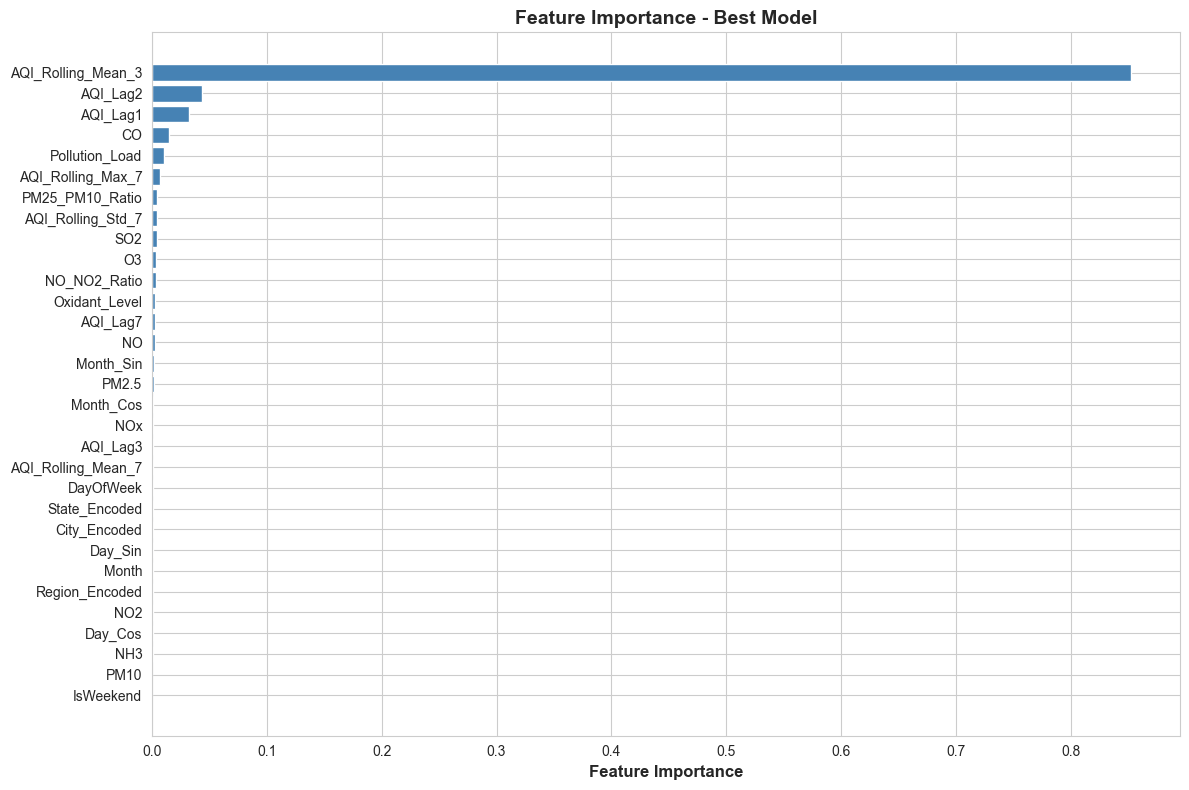

In [44]:
## Step 8: Feature Importance (Best Model)
import numpy as np
import matplotlib.pyplot as plt

if 'RF' in best['Model']:
    best_model = best_rf
else:
    best_model = best_xgb

importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 8))
plt.barh(range(X_train_imputed.shape[1]), importances[indices], color='steelblue')
plt.yticks(range(X_train_imputed.shape[1]), [X_train.columns[i] for i in indices])
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title('Feature Importance - Best Model', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 9: Cross-Validation Scores

In [45]:
## Step 9: Cross-Validation Scores
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train_imputed, y_train, cv=5, scoring='r2')
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

Cross-Validation Scores: [0.99452937 0.99639405 0.99418181 0.99295076 0.99543145]
Mean CV R²: 0.9947 (+/- 0.0023)


### Explanation:

- **cross_val_score(cv=5)**: 5-fold cross-validation (robust performance estimate).

- **Mean +/- 2*std**: Shows average performance and variability.

## Step 10: Save Final Model

In [46]:
## Step 10: Save Final Model
import joblib
import os

joblib.dump(best_model, os.path.join('..', 'models', 'final_optimized_model.pkl'))
comparison.to_csv(os.path.join('..', 'outputs', 'ensemble_comparison.csv'), index=False)
print(f'Final model ({best["Model"]}) saved to models/ folder!')
print('\n=== ALL 10 NOTEBOOKS COMPLETED ===')

Final model (Stacking Ensemble) saved to models/ folder!

=== ALL 10 NOTEBOOKS COMPLETED ===


## Summary

Ensemble Methods & Optimization:
1. Voting Ensemble (model averaging)
2. Stacking Ensemble (meta-learner)
3. GridSearchCV (exhaustive hyperparameter search)
4. RandomizedSearchCV (random hyperparameter search)
5. Model comparison and selection
6. Feature importance analysis
7. Cross-validation scores
8. Final optimized model saved

## 🎉 COMPLETE PROJECT SUMMARY

**All 10 Notebooks:**
1. Data Loading, Cleaning & Initial Exploration
2. Advanced EDA & Statistical Analysis
3. Time Series Analysis & Seasonal Decomposition
4. Feature Engineering & Data Preprocessing
5. ML Regression Models (AQI Prediction)
6. ML Classification Models (AQI Bucket)
7. Deep Learning LSTM Forecasting
8. SHAP Model Interpretation
9. Advanced Analytics & Statistical Tests
10. Ensemble Methods & Model Optimization

**Total Analysis:**
- 442,987 records analyzed
- 108+ Indian cities
- 10 years of data (2015-2024)
- 7 regression models
- 5 classification models
- 1 LSTM neural network
- SHAP interpretation
- Statistical tests (t-test, ANOVA, Chi-square)
- PCA & Clustering
- Ensemble methods
- Hyperparameter optimization

**PROJECT COMPLETE! 🎓**